# 🌲 Random Forests — In Depth
## 1. What is a Random Forest?
   - A Random Forest is an ensemble (collection) of Decision Trees that work together to make a more accurate and stable prediction.
   - How it works:
     1. Bootstrap Sampling — Randomly select samples (with replacement) from the dataset for each tree.
     2. Feature Randomness — Each tree considers only a subset of features at each split.
     3. Voting / Averaging —
        - For classification → Majority vote
        - For regression → Average of all trees
    - This randomness helps the forest avoid overfitting and improve generalization.
## 2. Advantages
   - ✅ Handles nonlinear relationships
   - ✅ Reduces overfitting (averaging multiple trees)
   - ✅ Works well with missing data & categorical features
   - ✅ Provides feature importance


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("synthetic_liver_cancer_dataset.csv")
data.head()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1,Regular,Former,0,0,51.9,16.44,0,0,Low,0,0
1,81,Female,19.9,Occasional,Never,0,0,41.6,8.09,0,0,Moderate,1,0
2,58,Female,25.5,Never,Never,0,0,76.0,0.64,0,0,Moderate,0,0
3,44,Male,16.0,Never,Former,0,0,50.3,19.09,0,0,Low,1,0
4,72,Male,21.0,Occasional,Former,0,0,39.5,4.95,1,0,Low,1,1


In [4]:
data['alcohol_consumption'] = data.alcohol_consumption.map({'Regular':0, 'Occasional':1, 'Never':2})
data['smoking_status'] = data.smoking_status.map({'Former':0, 'Never':1, 'Current':2})
data['physical_activity_level'] = data.physical_activity_level.map({'Low':0, 'Moderate':1, 'High':2})
data.head()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1,0,0,0,0,51.9,16.44,0,0,0,0,0
1,81,Female,19.9,1,1,0,0,41.6,8.09,0,0,1,1,0
2,58,Female,25.5,2,1,0,0,76.0,0.64,0,0,1,0,0
3,44,Male,16.0,2,0,0,0,50.3,19.09,0,0,0,1,0
4,72,Male,21.0,1,0,0,0,39.5,4.95,1,0,0,1,1


In [5]:
data = data.drop('gender', axis=1)

<Axes: >

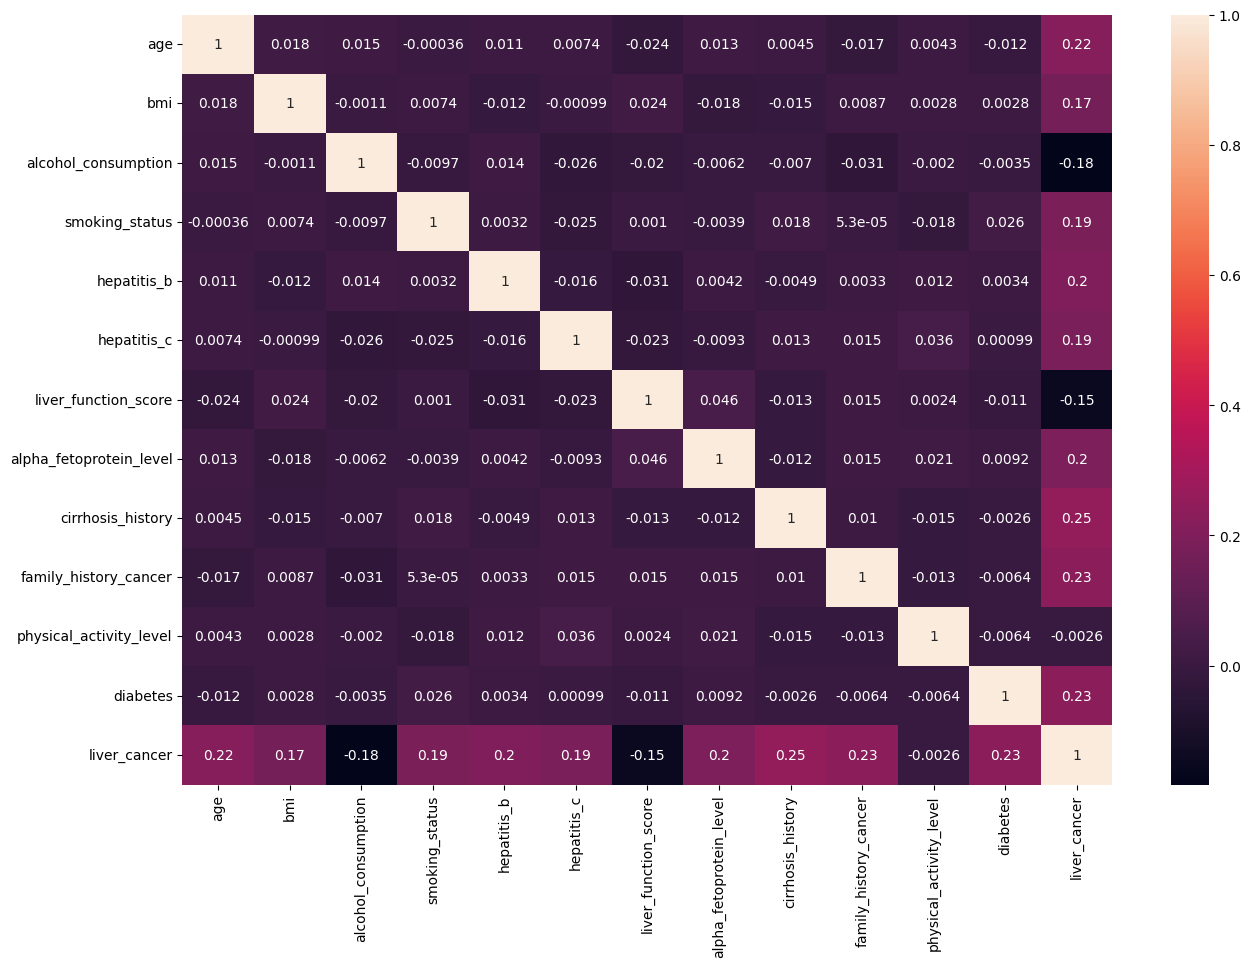

In [6]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(), annot = True)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
RF_classifier = RandomForestClassifier()

In [11]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.30, random_state=42)

In [12]:
RF_classifier.fit(x_train,y_train)

RandomForestClassifier()

In [15]:
train_pred = RF_classifier.predict(x_train)
test_pred = RF_classifier.predict(x_test)

Training Acc: 1.0


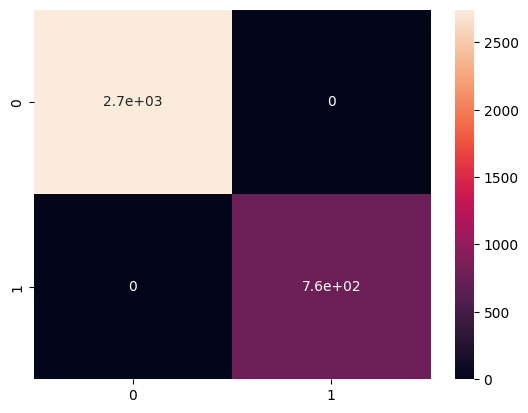

Testing Acc: 0.928


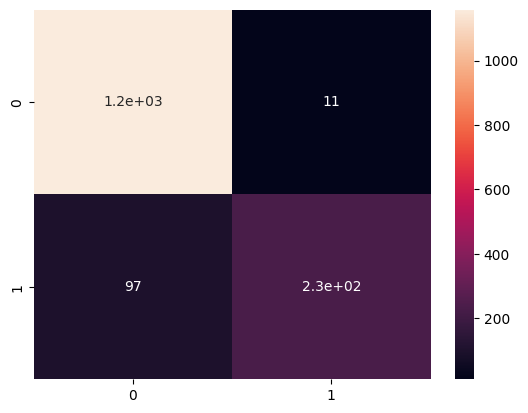

In [18]:
print("Training Acc:",accuracy_score(y_train,train_pred))
sns.heatmap(confusion_matrix(y_train,train_pred), annot=True)
plt.show()
print("Testing Acc:",accuracy_score(y_test,test_pred))
sns.heatmap(confusion_matrix(y_test,test_pred),annot=True)
plt.show()

<Axes: >

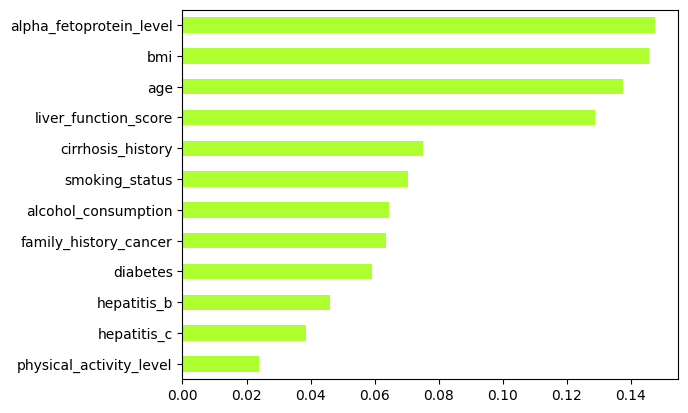

In [25]:
feature_importance = pd.Series(RF_classifier.feature_importances_, data.columns[:-1])
feature_importance.sort_values().plot(kind = 'barh', color = "greenyellow")

## 3. Hyperparameters to Experiment With
   
| Parameter	| Description	| Example |
| --- | --- | --- |
| n_estimators | Number of trees in the forest	| 100, 500 |
| max_depth	| Maximum depth of each tree | 3, 5, 10 |
| max_features | Number of features to consider for each split | "sqrt", "log2"|
| bootstrap | Whether bootstrap samples are used | True/False |
| criterion | Split quality metric | "gini" or "entropy" |

- Try tuning them using GridSearchCV or RandomizedSearchCV.

## 4. Key Concepts 
| Concept          | Random Forest Benefit                      |
| ---------------- | ------------------------------------------ |
| Overfitting      | Reduced by averaging multiple trees        |
| Accuracy         | Usually higher than a single decision tree |
| Interpretability | Can view feature importance                |
| Flexibility      | Handles both regression & classification   |
